In [1]:
%cd ..
# !curl -L -o .\data\sprites.zip https://www.kaggle.com/api/v1/datasets/download/ebrahimelgazar/pixel-art
# !Expand-Archive -LiteralPath '.\data\sprites.zip'

/Users/daanwichmann/PycharmProjects/BSc Thesis


## Importing dependencies

In [2]:
import os
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from project.models import EDM

In [3]:
device = "cpu"
if torch.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
print(f"Using: {device}")

Using: mps


## Setting hyperparameters

In [4]:
DATA = os.path.join("data", "sprites")
CHECKPOINT = os.path.join("parameters", "sprites")

In [5]:
BATCH_SIZE = 128
RESOLUTION = 32
IN_CHANNELS = 3
OUT_CHANNELS = 3
START_CHANNELS = 128
NUM_RES_BLOCKS = 2
CHANNEL_MULTIPLIERS = (1, 2, 2, 2)
ATTENTION_RESOLUTIONS = (16,)
LR = 1e-3
DROPOUT = 0.13

In [6]:
network_kwargs = {
    "resolution": RESOLUTION,
    "in_channels": IN_CHANNELS,
    "out_channels": OUT_CHANNELS,
    "start_channels": START_CHANNELS,
    "num_res_blocks": NUM_RES_BLOCKS,
    "channel_multipliers": CHANNEL_MULTIPLIERS,
    "attention_resolutions": ATTENTION_RESOLUTIONS,
    "dropout": DROPOUT,
}

## Preparing dataset & dataloader

In [7]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=0.5,
        std=0.5
    )  # Normalize image between [-1, 1]
])

In [8]:
data = datasets.ImageFolder(
    root=DATA,
    transform=transform,
)
loader = DataLoader(data, batch_size=BATCH_SIZE, shuffle=True)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.7882353].


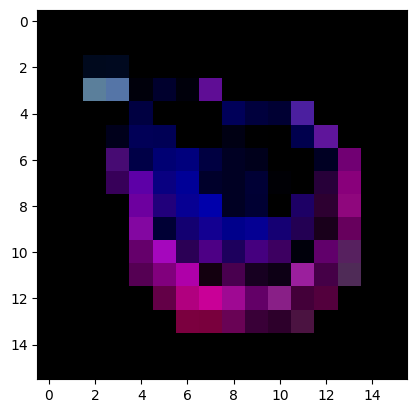

In [9]:
image, y = data[50]

plt.imshow(image.permute((1, 2, 0)))
plt.show()

## Setting up the model

In [10]:
model = EDM(
    image_resolution=RESOLUTION,
    image_channels=IN_CHANNELS,
    network_kwargs=network_kwargs
).to(device)

In [11]:
if os.path.exists(CHECKPOINT):
    model.load_checkpoint(CHECKPOINT)
    print("Loaded checkpoint!")

## Training the model

In [12]:
model.train(1, loader)

Epoch 1:   1%|          | 6/699 [00:20<34:08,  2.96s/it]

KeyboardInterrupt: 

In [ ]:
model.save_checkpoint(CHECKPOINT)